In [167]:
import numpy as np
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.tools import add_constant
import matplotlib.pyplot as plt
from numpy.random import normal, seed
from numpy import arange, var, mean, std
from pandas import DataFrame
from matplotlib import style
style.use("fivethirtyeight")
# seed = 1

In [260]:
# True model
def f(x1, x2):
    b1 =  0.5
    b2 =  0.5
    b3 = -0.9
    y = b1*x1 + b2*x2 + b3*(x1*x2)
    return y


# Data collection
def collect_data(N, measure_y, measure_x=False, measure_x1=False, measure_x2=False):
    assert measure_y, "You need to measure something to collect data!"
    _x1 = normal(0, 1, N)
    _x2 = normal(0, 1, N)
    σ2 = 1.5**2
    ε = normal(0, σ2**.5, N)
    y = f(_x1, _x2) + ε
    data = {"index": arange(y.size), "y": y}
    if measure_x or measure_x1:
        data["x"] = _x1
    if measure_x2:
        data.pop("x")
        data["x1"] = _x1
        data["x2"] = _x2
    return DataFrame(data)


# Traditional Approach

## Step 0
I noticed that `y` varies.

,index,y
0,0,-0.182330
1,1,1.432607
2,2,-1.937136
3,3,0.895117
4,4,1.082400


(Residual) variance of y = 3.87


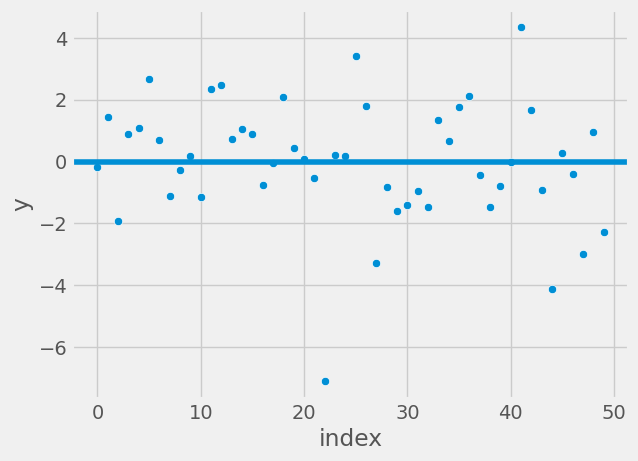

In [277]:
# Conduct experiment and get noisy data
df = collect_data(
    N = 50, 
    measure_y = True
)

# Explore data
display(df.head())
sns.scatterplot(x="index", y="y", data=df)

# Fit a (very simple) model
model = ols("y ~ 1", data=df).fit()
plt.gca().axhline(model.params[0])

# Evaluate
v_hat = sum((df.y - df.y.mean())**2) / (50 - 1)
print(f"(Residual) variance of y = {v_hat:.2f}")

Okay, variance seems a little too high to be just noise. Perhaps, there is more to it...

# Step 1
Hmmm, perhaps `x` predicts `y`?

,index,y,x
0,0,0.710725,0.096684
1,1,0.671524,1.582193
2,2,0.402233,1.256235
3,3,1.617500,0.582785
4,4,1.826242,1.138027


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     15.22
Date:                Fri, 14 Jul 2023   Prob (F-statistic):           0.000297
Time:                        17:42:23   Log-Likelihood:                -88.087
No. Observations:                  50   AIC:                             180.2
Df Residuals:                      48   BIC:                             184.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1940      0.206     -0.943      0.351      -0.608       0.220
x              0.7374      0.189      3.901      0.000       0.357       1.117
==============================================================================
Omnibus:                        3.394   Durbin-Watson:                   2.197
Prob(Omnibus):                  0.183   Jarque-Bera (JB):                2.366
Skew:                           0.386   Prob(JB):                        0.306
Kurtosis:                       3.735   Cond. No.                         1.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

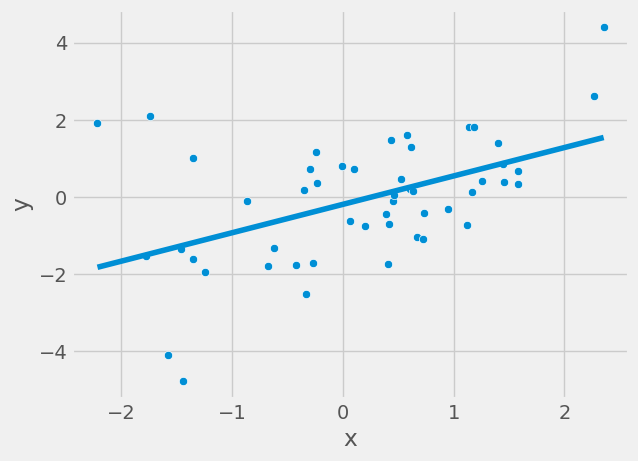

In [259]:
# Conduct experiment and get noisy data
df = collect_data(
    N = 50, 
    measure_y = True,
    measure_x = True,
)

# Explore data
display(df.head())
sns.scatterplot(x="x", y="y", data=df)

# Fit a (very simple) model
model = ols("y ~ x", data=df).fit()
df = df.sort_values(by='x')
plt.gca().plot(df.x, model.predict(df.x))

# Evaluate
model.summary()

In [255]:
a = normal(0, 10**.5, 100000)
b = normal(0, 20**.5, 100000)
c = normal(0, 30**.5, 100000)

print(var(a + b + c))
print(var(a) + var(b) + var(c))
print(var(a), var(b), var(c))

60.24884239240849
59.9226263485513
10.00007452278461 20.059373680760604 29.86317814500608
